# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
Name:Suneel kumar

Student ID:023-24-0527


Section:B

GitHub:https://github.com/WadhwaniSuneel/ML1

Kaggle:https://www.kaggle.com/suneelwadhwani

**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [28]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [29]:
# Task 1 — load and verify the cleaned dataset
df=pd.read_csv('BSOxkA.csv')

df.shape
df.info()
df.describe()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Answer 2 (Lab 3/4 recap):**
In Lab 3, we trained a Decision Tree model and evaluated it using accuracy, precision, recall, and F1-score. In Lab 4, we used Random Forest and evaluated it using the same metrics.

---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [30]:
# Task 3 — define X and y (same as Lab 3/4)

df = df.drop(columns=["customerID"])

df["TotalCharges"] = pd.to_numeric( df["TotalCharges"], errors="coerce" )

# Convert binary columns to 0/1
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]
for col in binary_cols: df[col] = df[col].map({ "No": 0, "Yes": 1 })

# Convert target to 0/1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

df["TotalCharges"] = df["TotalCharges"].fillna( df["TotalCharges"].median() )

X = df.drop("Churn", axis=1)
y = df["Churn"]

# One-hot encode remaining categorical data
X = pd.get_dummies(X, drop_first=True)

X = X.astype(int)

display(X.head())
display(y.head()) 
print("X shape:", X.shape) 
print("y shape:", y.shape) 
print("\nTarget data type:") 
print(y.dtype)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29,29,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56,1889,1,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53,108,1,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42,1840,1,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70,151,0,0,...,0,0,0,0,0,0,0,0,1,0


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

X shape: (7043, 30)
y shape: (7043,)

Target data type:
int64


**Answer 4:**
Feature scaling is important for KNN because it uses distances, so features with larger values could dominate the results. Logistic Regression also benefits from scaling, while Decision Tree and Random Forest do not require scaling because they make decisions using feature-based splits rather than distances.

In [31]:
# Task 5 — train/test split, then fit/apply StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME fitted scaler to test data
X_test_scaled = scaler.transform(X_test)


**Answer 5 (why fit scaler on training data only):**
The scaler should be fitted only on the training data so that information from the test set does not influence the model. This prevents data leakage and ensures that the test set remains unseen during training.

---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [32]:
# Task 6 — train Logistic Regression, predict on scaled test set
logreg = LogisticRegression(random_state=42)

# Train the model
logreg.fit(X_train_scaled, y_train)

# Predict on the scaled test data
y_pred = logreg.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

print("Actual values:")
print(y_test.values[:10])

print("\nPredicted values:")
print(y_pred[:10])

Predictions:
[0 1 0 ... 0 0 0]
Actual values:
[0 0 0 0 0 0 0 0 0 1]

Predicted values:
[0 1 0 0 0 1 0 0 0 0]


Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506

Confusion Matrix:
[[925 110]
 [162 212]]


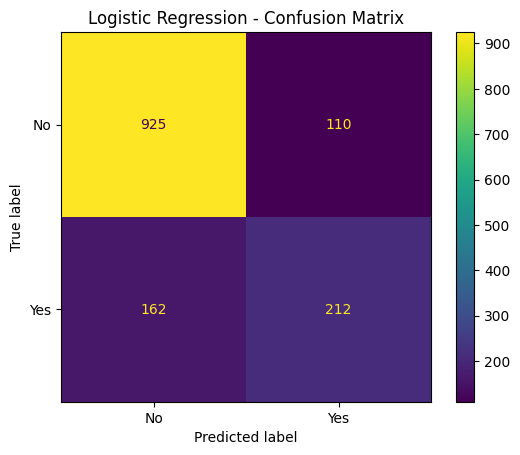

In [33]:
# Task 7 — metrics + confusion matrix
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


**Task 7 — Logistic Regression Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.80 |
| Precision |0.65|
| Recall |0.56|
| F1-score |0.60|

In [34]:
# Task 8 — inspect predict_proba for a few test customers
y_proba = logreg.predict_proba(X_test_scaled)

# Display probabilities for the first 5 test customers
proba_df = pd.DataFrame(
    y_proba[:5],
    columns=["Probability_No_Churn", "Probability_Churn"]
)

display(proba_df)

results = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": logreg.predict(X_test_scaled)[:5],
    "P(No Churn)": y_proba[:5, 0],
    "P(Churn)": y_proba[:5, 1]
})

display(results)

,Probability_No_Churn,Probability_Churn
0,0.956014,0.043986
1,0.318281,0.681719
2,0.943055,0.056945
3,0.595377,0.404623
4,0.978430,0.021570


,Actual,Predicted,P(No Churn),P(Churn)
0,0,0,0.956014,0.043986
1,0,1,0.318281,0.681719
2,0,0,0.943055,0.056945
3,0,0,0.595377,0.404623
4,0,0,0.978430,0.021570


**Answer 8:**
predict_proba() gives the probability of each possible class, such as No Churn and Churn. It helps us understand how confident the Logistic Regression model is about its prediction, while predict() gives the final predicted class.

---

## 4. KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled your Decision Tree's complexity in Lab 3.

*Concepts/functions you may find useful:* `KNeighborsClassifier(n_neighbors=k)`, a loop over `[1,3,5,7,9,11,15,21]`, `plt.plot(...)`

**Tasks**
9. Train KNN classifiers for several values of K on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [35]:
# Task 9 — loop over K values, record accuracy and F1
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train the model
    knn.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_knn_pred = knn.predict(X_test_scaled)
    
    # Calculate Accuracy
    accuracy = accuracy_score(y_test, y_knn_pred)
    f1 = f1_score(y_test, y_knn_pred, pos_label=1)
    
    # Store results
    knn_results.append({
        "K": k,
        "Accuracy": accuracy,
        "F1-score": f1
    })

# Convert results into DataFrame
knn_results_df = pd.DataFrame(knn_results)

display(knn_results_df)


,K,Accuracy,F1-score
0,1,0.716820,0.478431
1,3,0.745209,0.512890
2,5,0.747339,0.508287
3,7,0.760823,0.529986
4,9,0.770759,0.558140
5,11,0.772179,0.559671
6,15,0.770759,0.554483
7,21,0.772179,0.564450


**Task 9 — K Selection Results**

| K | Accuracy | F1-score |
|---|---|---|
| 1 |0.71|0.47 |
| 3 |0.74|0.51 |
| 5 |0.74|0.50 |
| 7 |0.76|0.52 |
| 9 |0.77|0.55 |
| 11 |0.77|0.55 |
| 15 |0.77|0.55 |
| 21 |0.77|0.56 |

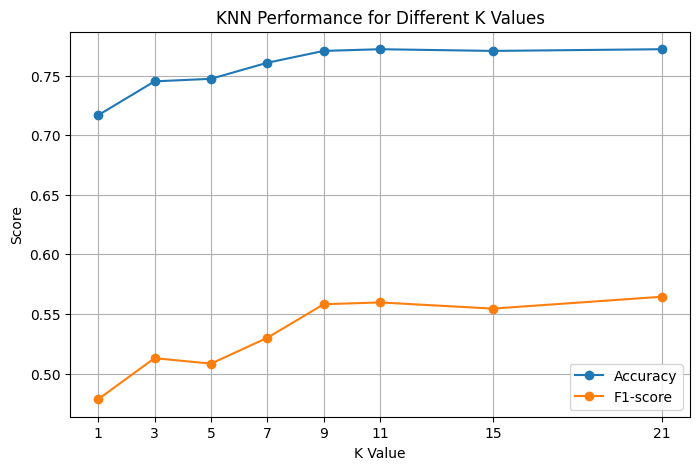

In [36]:
# Task 10 — plot accuracy/F1 vs K
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results_df["K"],
    knn_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    knn_results_df["K"],
    knn_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("K Value")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")

plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

**Answer 10 (chosen K and why):**
I would choose K = 9 because it gives a good balance between accuracy and F1-score on the test set. I would not choose the smallest K because it can be sensitive to individual data points and may overfit, while a very large K can make the model too general and reduce its ability to capture useful patterns.

Final KNN Results
-----------------
Chosen K : 9
Accuracy : 0.7707594038325053
Precision: 0.5714285714285714
Recall   : 0.5454545454545454
F1-score : 0.5581395348837209

Confusion Matrix:
[[882 153]
 [170 204]]


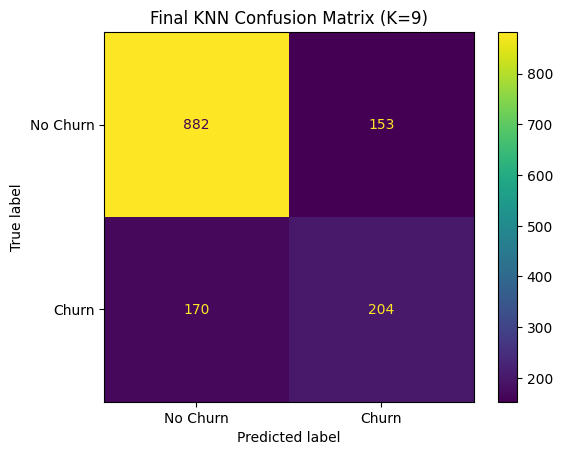

In [37]:
# Task 11 — final KNN model at chosen K: metrics + confusion matrix
best_k = 9
final_knn = KNeighborsClassifier(n_neighbors=best_k)

# Train the model
final_knn.fit(X_train_scaled,y_train)

# Predict on test data
y_knn_pred = final_knn.predict(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_knn_pred)
precision = precision_score(y_test, y_knn_pred)
recall = recall_score(y_test, y_knn_pred)
f1 = f1_score(y_test, y_knn_pred)

# Display metrics
print("Final KNN Results")
print("-----------------")
print("Chosen K :", best_k)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_knn_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title(f"Final KNN Confusion Matrix (K={best_k})")
plt.show()

**Task 11 — Final KNN Metrics (K = 9)**

| Metric | Value |
|---|---|
| Accuracy |0.77 |
| Precision |0.57|
| Recall |0.54|
| F1-score |0.55|

---

## 5. Model Comparison (4 Models)

Place all four classifiers you've built side by side.

**Task**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [38]:
# Task 12 — assemble the 4-model comparison table (retrain DT/RF quickly if needed)
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_dt_pred)
dt_precision = precision_score(y_test, y_dt_pred)
dt_recall = recall_score(y_test, y_dt_pred)
dt_f1 = f1_score(y_test, y_dt_pred)

# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_rf_pred)
rf_precision = precision_score(y_test, y_rf_pred)
rf_recall = recall_score(y_test, y_rf_pred)
rf_f1 = f1_score(y_test, y_rf_pred)

# 3. Logistic Regression
y_logreg_pred = logreg.predict(X_test_scaled)

logreg_accuracy = accuracy_score(y_test, y_logreg_pred)
logreg_precision = precision_score(y_test, y_logreg_pred)
logreg_recall = recall_score(y_test, y_logreg_pred)
logreg_f1 = f1_score(y_test, y_logreg_pred)


# 4. Final KNN
y_knn_pred = final_knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_knn_pred)
knn_precision = precision_score(y_test, y_knn_pred)
knn_recall = recall_score(y_test, y_knn_pred)
knn_f1 = f1_score(y_test, y_knn_pred)


# 5. Create comparison table
comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],
    
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        logreg_accuracy,
        knn_accuracy
    ],
    
    "Precision": [
        dt_precision,
        rf_precision,
        logreg_precision,
        knn_precision
    ],
    
    "Recall": [
        dt_recall,
        rf_recall,
        logreg_recall,
        knn_recall
    ],
    
    "F1-score": [
        dt_f1,
        rf_f1,
        logreg_f1,
        knn_f1
    ]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.722498,0.477333,0.478610,0.477971
1,Random Forest,0.792051,0.636364,0.505348,0.563338
2,Logistic Regression,0.806955,0.658385,0.566845,0.609195
3,KNN,0.770759,0.571429,0.545455,0.558140


**Task 12 — 4-Model Comparison Table**

| Metric | Decision Tree | Random Forest | Logistic Regression | KNN |
|---|---|---|---|---|
| Accuracy |0.72|0.79|0.80|0.77|
| Precision |0.47|0.63|0.65|0.57|
| Recall |0.47|0.50|0.56|0.54|
| F1-score |0.47|0.56|0.60|0.55|

**Answer 13:**
The best overall model is the one with the strongest F1-score, because it provides a good balance between precision and recall. Since the dataset has class imbalance, I would give more importance to recall and F1-score rather than accuracy alone, because correctly identifying customers who are likely to churn is important.

---

## 6. Coefficient Interpretation

Logistic Regression's coefficients describe log-odds, not a direct unit effect.

*Concepts/functions you may find useful:* `model.coef_`, `model.intercept_`, `np.exp(coefficient)` (converts log-odds to an odds ratio)

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [39]:
# Task 14 — extract coefficients, compute odds ratios
coefficients = logreg.coef_[0]

feature_names = X.columns

# Calculate odds ratios
odds_ratios = np.exp(coefficients)

# Create a DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})

# Sort by absolute coefficient value
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

# Display the results
display(coef_df)

print("Top 10 features by coefficient magnitude:")
display(coef_df.head(10))

,Feature,Coefficient,Odds Ratio,Absolute Coefficient
3,tenure,-1.230331,0.292196,1.230331
6,MonthlyCharges,-0.821975,0.439563,0.821975
11,InternetService_Fiber optic,0.736356,2.088311,0.736356
26,Contract_Two year,-0.589700,0.554494,0.589700
7,TotalCharges,0.508344,1.662536,0.508344
25,Contract_One year,-0.285952,0.751298,0.285952
24,StreamingMovies_Yes,0.242159,1.273997,0.242159
22,StreamingTV_Yes,0.241368,1.272990,0.241368
10,MultipleLines_Yes,0.208239,1.231507,0.208239
5,PaperlessBilling,0.182152,1.199796,0.182152


Top 10 features by coefficient magnitude:


,Feature,Coefficient,Odds Ratio,Absolute Coefficient
3,tenure,-1.230331,0.292196,1.230331
6,MonthlyCharges,-0.821975,0.439563,0.821975
11,InternetService_Fiber optic,0.736356,2.088311,0.736356
26,Contract_Two year,-0.589700,0.554494,0.589700
7,TotalCharges,0.508344,1.662536,0.508344
25,Contract_One year,-0.285952,0.751298,0.285952
24,StreamingMovies_Yes,0.242159,1.273997,0.242159
22,StreamingTV_Yes,0.241368,1.272990,0.241368
10,MultipleLines_Yes,0.208239,1.231507,0.208239
5,PaperlessBilling,0.182152,1.199796,0.182152


**Task 14 — Coefficient / Odds Ratio Table**

| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---|---|---|
|tenure        |-1.23 |0.29|Negative coefficient means higher tenure is associated with lower churn. The odds ratio of 0.29 means the odds of churn decrease as tenure increases. |
|monthlycharges|-0.82|0.43| Negative coefficient means higher monthly charges are associated with lower churn. The odds ratio of 0.43 indicates lower odds of churn.|
|InternetService_Fiber optic          |0.73|2.08|Positive coefficient means customers with Fiber optic service have higher churn tendency. The odds ratio of 2.08 means their odds of churn are about 2.08 times higher. |
|Contract_Two year|-0.58|0.55| Negative coefficient means customers with a two-year contract are less likely to churn. The odds ratio of 0.55 indicates lower odds of churn compared with the reference contract category.|

**Answer 15:**
Tenure and two-year contracts are associated with lower churn, while Fiber optic internet service is associated with higher churn. Monthly charges also show lower churn odds according to the given coefficient and odds ratio values.

---

## 7. Final Model Selection & Conclusion

Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Section 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model and justification):**
I would select the model with the best overall F1-score from the Section 5 comparison table as the final model. This is because F1-score balances precision and recall, which is more useful for this imbalanced churn dataset than relying only on accuracy. I would also consider the results across all four metrics and not trust a single performance number when making the final choice.

**Answer 17 — Conclusion:**
In this lab, I compared Logistic Regression and KNN with the Decision Tree and Random Forest models from the earlier labs. Feature scaling was especially important for KNN and Logistic Regression because these models are affected by the scale of the features. The final model was selected based on the overall comparison of accuracy, precision, recall, and F1-score rather than one metric alone. The imbalanced churn classes also showed why recall and F1-score are important when evaluating the models. Although the selected model performed well, it may still make incorrect predictions for some customers. In the future, I would try further hyperparameter tuning, cross-validation, and other techniques to improve the model's performance.

---

## Submission Checklist

Before submitting, confirm you have:

- [✓ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ✓] Section 1 — Problem Definition & Dataset Verification (with Lab 3/4 recap)
- [✓ ] Section 2 — Feature Scaling & Preparation (scaler fit on training data only, explained)
- [ ✓] Section 3 — Logistic Regression (all four metrics + confusion matrix + predict_proba discussion)
- [✓ ] Section 4 — KNN & Choosing K (results table, plot, justified K choice, final metrics)
- [✓ ] Section 5 — Model Comparison (all four models, all four metrics)
- [✓ ] Section 6 — Coefficient Interpretation (odds ratios + connection to earlier labs)
- [✓ ] Section 7 — Final Model Selection & Conclusion
- [✓ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted